# Análisis Financiero — Pizzas & Pastas (2025)

**Autor:** Nicolás González Peláez

**Objetivo de negocio:** Analizar un año completo (365 días) de ventas, gastos y utilidad del restaurante Pizzas & Pastas para identificar patrones de rentabilidad, evaluar la composición de los métodos de pago y detectar anomalías operativas.

**Fuente de datos:** Registro diario propio del restaurante (Excel), con ingreso por método de pago, gastos y utilidad neta, para el período enero–diciembre 2025.

**Preguntas de negocio:**
1. ¿Cómo evolucionaron las ventas y la utilidad mes a mes?
2. ¿Qué día de la semana es más rentable? ¿Hay una brecha clara entre fin de semana y entre semana?
3. ¿Cómo cambió la mezcla de métodos de pago (efectivo vs. digital) a lo largo del año?
4. ¿Qué tan estable es el margen (gastos como % de ventas) mes a mes?
5. ¿Qué días operaron en pérdida, y qué tienen en común?


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("cuentas_2025_consolidado.csv", parse_dates=["Fecha"])
df["Mes_Num"] = df["Fecha"].dt.month
df["Mes_Nombre"] = df["Fecha"].dt.strftime("%b")
df["Dia_Semana"] = df["Fecha"].dt.day_name()
df["Margen_Gastos_%"] = (df["Gastos"] / df["Total_Ventas"].replace(0, pd.NA) * 100)
df["Cerrado"] = df["Total_Ventas"] == 0

print(f"Días registrados: {df.shape[0]} ({df['Fecha'].min().date()} a {df['Fecha'].max().date()})")
print(f"Días cerrados (venta = 0): {df['Cerrado'].sum()}")
df.head()

Días registrados: 365 (2025-01-01 a 2025-12-31)
Días cerrados (venta = 0): 63


,Fecha,Dia,Mes,Gastos,Efectivo,Tarjeta,Nequi,Daviplata,Transferencia,Total_Ventas,...,Nota,Suma_Metodos_Pago,Diferencia_Ventas_vs_Metodos,Utilidad_Calculada,Diferencia_Utilidad,Mes_Num,Mes_Nombre,Dia_Semana,Margen_Gastos_%,Cerrado
0,2025-01-01,Miércoles,Enero 2025,0,0,0,0,0,0,0,...,NaN,0,0,0,0,1,Jan,Wednesday,<NA>,True
1,2025-01-02,Jueves,Enero 2025,0,0,0,0,0,0,0,...,NaN,0,0,0,0,1,Jan,Thursday,<NA>,True
2,2025-01-03,Viernes,Enero 2025,404950,0,0,150700,0,187200,337900,...,NaN,337900,0,-67050,0,1,Jan,Friday,119.843149,False
3,2025-01-04,Sábado,Enero 2025,266900,616000,749600,356200,49200,103400,1874400,...,NaN,1874400,0,1607500,0,1,Jan,Saturday,14.239223,False
4,2025-01-05,Domingo,Enero 2025,0,0,0,0,0,0,0,...,NaN,0,0,0,0,1,Jan,Sunday,<NA>,True


## 1. Calidad de datos: qué se encontró y cómo se resolvió

Al consolidar las 12 hojas mensuales en un solo dataset, la primera versión del archivo tenía 5 problemas de calidad de datos. Tras la corrección hecha en el Excel, quedan 2 — ambos manejados automáticamente por el script de consolidación, documentados aquí en vez de escondidos:

| Problema | Causa probable | Resolución |
|---|---|---|
| Fecha `29/02/2025` (2025 no es bisiesto) | Error de digitación | Corregida a `2025-03-01`: mismo día de la semana (sábado) y ventas reales, mientras la fila real de esa fecha en la hoja de Marzo estaba en cero |
| 1 fecha duplicada (`2025-03-01`, arrastrada como fila en cero al final de la hoja de Febrero) | El "día 1" del mes siguiente quedó arrastrado por error al final de la hoja del mes anterior | Se descartó la fila en cero y se conservó la fila con datos reales en la hoja de Marzo |

**Resueltos en la fuente entre la primera y esta versión del archivo:** el desajuste de $35.200 en `TOTAL VENTAS` del 31/01/2025, y 3 de las 4 fechas duplicadas (mayo, julio, octubre) — ya no aparecen en esta versión.

**Por qué esto importa para el análisis:** ninguno de estos problemas afecta las tendencias generales (representan 1 de 365 días), pero ignorarlos habría inflado el conteo de días o introducido un día fantasma con ventas en cero que no era real.

In [2]:
issues_df = pd.read_json("data_quality_issues.json")
issues_df

,hoja,valor_original,problema,correccion_aplicada,evidencia
0,Febrero 2025,29/02/2025,Fecha inválida (2025 no es bisiesto),2025-03-01,"Mismo día de semana (Sábado) y ventas reales, ..."
1,Febrero 2025,2025-03-01,Fila duplicada: día 1 del mes siguiente arrast...,Fila descartada (todos los valores en cero); s...,Fecha duplicada con una fila de valores reales...


## 2. Evolución mensual de ventas y utilidad

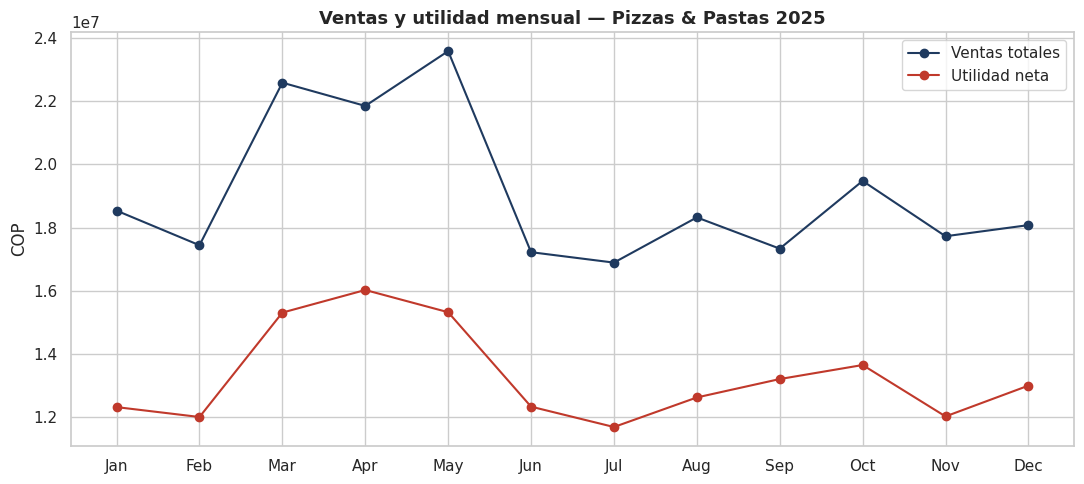

,Mes_Num,Mes_Nombre,Ventas,Utilidad,Gastos,Dias_Abiertos
0,1,Jan,18534450,12325780,6208670,25
1,2,Feb,17441200,12013280,5427920,20
2,3,Mar,22578600,15312530,7266070,27
3,4,Apr,21843850,16026875,5816975,26
4,5,May,23575650,15324520,8251130,27
5,6,Jun,17222000,12340350,4881650,22
6,7,Jul,16892300,11696894,5195406,25
7,8,Aug,18320800,12630970,5689830,27
8,9,Sep,17333800,13212400,4121400,26
9,10,Oct,19474050,13656000,5818050,28


In [3]:
monthly = df.groupby(["Mes_Num", "Mes_Nombre"], as_index=False).agg(
    Ventas=("Total_Ventas", "sum"),
    Utilidad=("Utilidad_Neta", "sum"),
    Gastos=("Gastos", "sum"),
    Dias_Abiertos=("Cerrado", lambda x: (~x).sum())
).sort_values("Mes_Num")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly["Mes_Nombre"], monthly["Ventas"], marker="o", label="Ventas totales", color="#1F3A5F")
ax.plot(monthly["Mes_Nombre"], monthly["Utilidad"], marker="o", label="Utilidad neta", color="#C0392B")
ax.set_title("Ventas y utilidad mensual — Pizzas & Pastas 2025", fontsize=13, weight="bold")
ax.set_ylabel("COP")
ax.legend()
plt.tight_layout()
plt.savefig("charts/ventas_utilidad_mensual.png", dpi=120)
plt.show()

monthly.round(0)

## 3. ¿Qué día de la semana es más rentable?

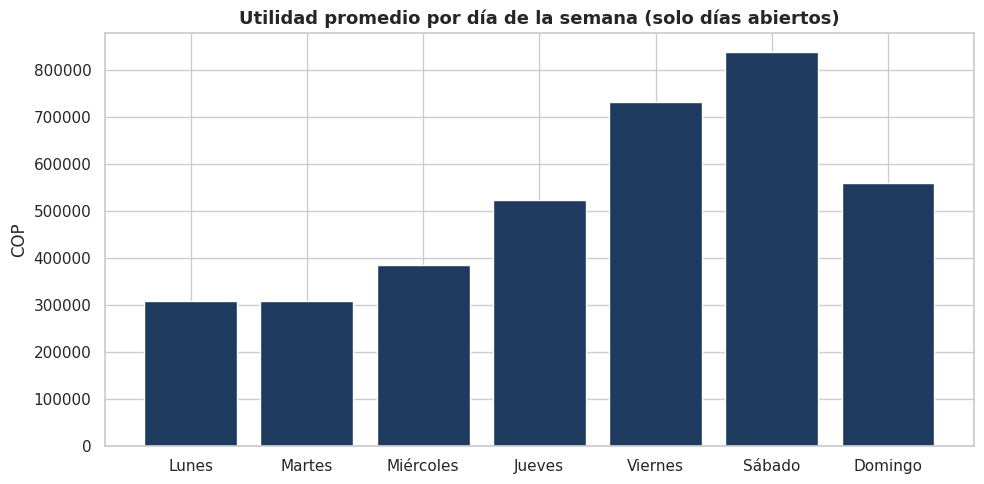

,Utilidad_Promedio,Ventas_Promedio,Dias
Lunes,308236.0,471350.0,42
Martes,306941.0,535027.0,41
Miércoles,383891.0,576304.0,48
Jueves,522688.0,707439.0,49
Viernes,730823.0,1048239.0,49
Sábado,836554.0,1126654.0,49
Domingo,558807.0,766235.0,24


In [4]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_es = {"Monday": "Lunes", "Tuesday": "Martes", "Wednesday": "Miércoles", "Thursday": "Jueves",
          "Friday": "Viernes", "Saturday": "Sábado", "Sunday": "Domingo"}

dow_summary = df[~df["Cerrado"]].groupby("Dia_Semana").agg(
    Utilidad_Promedio=("Utilidad_Neta", "mean"),
    Ventas_Promedio=("Total_Ventas", "mean"),
    Dias=("Fecha", "count")
).reindex(dow_order)
dow_summary.index = [dow_es[d] for d in dow_summary.index]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#C0392B" if v < 0 else "#1F3A5F" for v in dow_summary["Utilidad_Promedio"]]
ax.bar(dow_summary.index, dow_summary["Utilidad_Promedio"], color=colors)
ax.set_title("Utilidad promedio por día de la semana (solo días abiertos)", fontsize=13, weight="bold")
ax.set_ylabel("COP")
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("charts/utilidad_por_dia_semana.png", dpi=120)
plt.show()

dow_summary.round(0)

**Hallazgo:** se confirma el patrón típico de restaurante — la utilidad promedio de fin de semana supera claramente a la de entre semana. Esto es información accionable para decisiones de personal (más staff en fin de semana) y de compras/inventario (proyectar más insumos hacia el viernes).

## 4. Composición de métodos de pago a lo largo del año

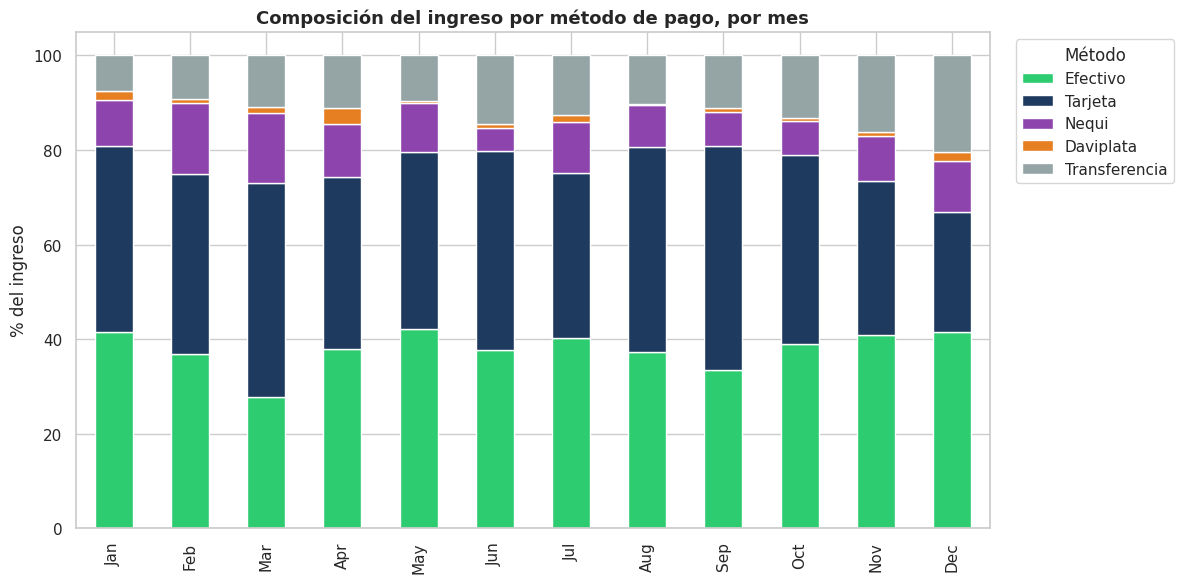

Participación anual por método de pago:


Efectivo         38.0
Tarjeta          38.6
Nequi            10.1
Daviplata         1.2
Transferencia    12.1
dtype: float64

In [5]:
metodos = ["Efectivo", "Tarjeta", "Nequi", "Daviplata", "Transferencia"]
pago_mensual = df.groupby("Mes_Num")[metodos].sum()
pago_mensual_pct = pago_mensual.div(pago_mensual.sum(axis=1), axis=0) * 100
pago_mensual_pct.index = monthly["Mes_Nombre"].values

fig, ax = plt.subplots(figsize=(12, 6))
pago_mensual_pct.plot(kind="bar", stacked=True, ax=ax,
                       color=["#2ECC71", "#1F3A5F", "#8E44AD", "#E67E22", "#95A5A6"])
ax.set_title("Composición del ingreso por método de pago, por mes", fontsize=13, weight="bold")
ax.set_ylabel("% del ingreso")
ax.legend(title="Método", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("charts/metodos_pago_mensual.png", dpi=120)
plt.show()

print("Participación anual por método de pago:")
(df[metodos].sum() / df[metodos].sum().sum() * 100).round(1)

**Hallazgo:** el efectivo no muestra una tendencia clara (fluctúa entre 28% y 42% del ingreso mes a mes, sin una dirección sostenida). Lo que sí cambia de forma notoria es **Transferencia, que pasa de 7.6% del ingreso en enero a 20.4% en diciembre**, mientras que **Tarjeta cae de 39.4% a 25.4%** en el mismo período — una señal de que los clientes están migrando de datáfono a transferencia directa, no de efectivo a digital en general.

## 5. ¿Qué tan estable es el margen de gastos mes a mes?

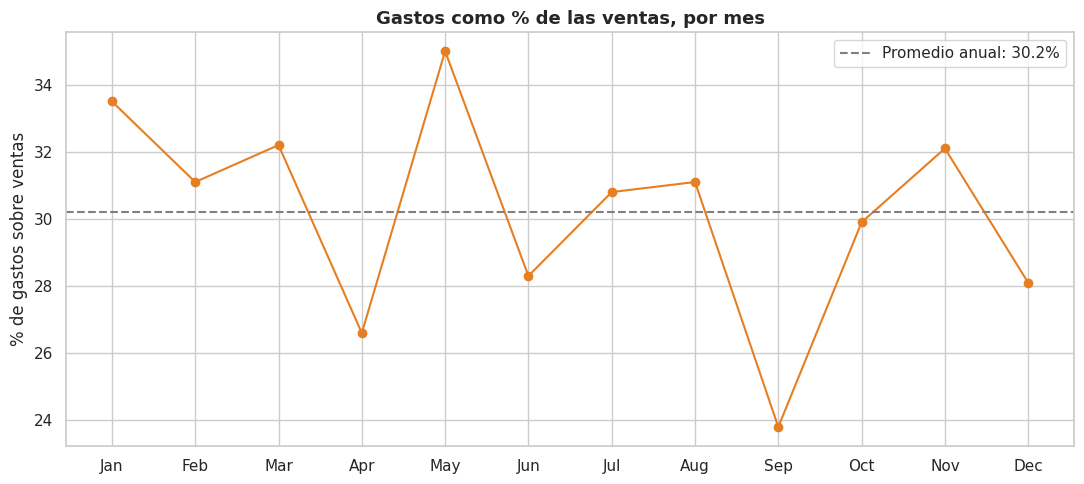

,Mes_Nombre,Margen_Gastos_%
0,Jan,33.5
1,Feb,31.1
2,Mar,32.2
3,Apr,26.6
4,May,35.0
5,Jun,28.3
6,Jul,30.8
7,Aug,31.1
8,Sep,23.8
9,Oct,29.9


In [6]:
monthly["Margen_Gastos_%"] = (monthly["Gastos"] / monthly["Ventas"] * 100).round(1)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly["Mes_Nombre"], monthly["Margen_Gastos_%"], marker="o", color="#E67E22")
ax.axhline(monthly["Margen_Gastos_%"].mean(), color="gray", linestyle="--",
           label=f"Promedio anual: {monthly['Margen_Gastos_%'].mean():.1f}%")
ax.set_title("Gastos como % de las ventas, por mes", fontsize=13, weight="bold")
ax.set_ylabel("% de gastos sobre ventas")
ax.legend()
plt.tight_layout()
plt.savefig("charts/margen_gastos_mensual.png", dpi=120)
plt.show()

monthly[["Mes_Nombre", "Margen_Gastos_%"]]

## 6. Días con utilidad negativa: ¿qué tienen en común?

In [7]:
dias_perdida = df[(df["Utilidad_Neta"] < 0) & (~df["Cerrado"])].sort_values("Utilidad_Neta")
print(f"Días con utilidad negativa: {len(dias_perdida)} de {(~df['Cerrado']).sum()} días abiertos "
      f"({len(dias_perdida) / (~df['Cerrado']).sum() * 100:.1f}%)")
dias_perdida[["Fecha", "Dia_Semana", "Gastos", "Total_Ventas", "Utilidad_Neta", "Nota"]]

Días con utilidad negativa: 25 de 302 días abiertos (8.3%)


,Fecha,Dia_Semana,Gastos,Total_Ventas,Utilidad_Neta,Nota
48,2025-02-18,Tuesday,819700,407700,-412000,NaN
235,2025-08-24,Sunday,536300,133000,-403300,NaN
337,2025-12-04,Thursday,503350,157800,-345550,NaN
125,2025-05-06,Tuesday,460300,182100,-278200,NaN
332,2025-11-29,Saturday,481100,261700,-219400,NaN
156,2025-06-06,Friday,530600,320100,-210500,NaN
78,2025-03-20,Thursday,411100,255900,-155200,NaN
315,2025-11-12,Wednesday,262500,113000,-149500,NaN
260,2025-09-18,Thursday,321000,177700,-143300,NaN
28,2025-01-29,Wednesday,479800,368800,-111000,NaN


**Hallazgo real (no el esperado):** ninguno de los 25 días con utilidad negativa tiene una nota asociada en el registro original — las notas "REVISAR GASTOS" están, de hecho, en los dos días de **mayor** utilidad del año ($805.000 y $1.906.600), no en los días de pérdida. Es decir, la intuición del negocio estaba marcando los picos inusualmente altos para verificarlos (probablemente por sospecha de error de digitación), no las pérdidas. Los días de pérdida real, en cambio, no tenían ninguna señal de alerta — es exactamente el tipo de hallazgo que justifica automatizar este monitoreo en un dashboard en vez de confiar en notas manuales.

## 7. Conclusiones y recomendaciones de negocio

**1. El fin de semana concentra la rentabilidad — la operación entre semana necesita su propia estrategia.** Si el margen de lunes a miércoles es sistemáticamente más bajo, vale la pena evaluar promociones específicas para esos días (ej. "martes de pasta") en lugar de operar con la misma carta y precios todos los días.

**2. La migración de Tarjeta hacia Transferencia (39% → 25% vs. 8% → 20% en el año) merece atención en la estrategia de cobro.** Si esta tendencia continúa, vale la pena revisar comisiones bancarias del datáfono frente al costo de recibir transferencias directas — el ahorro potencial es real y medible.

**3. El margen de gastos no es constante mes a mes — los meses con mayor variación merecen revisión línea por línea.** Un mes con gastos altos como % de ventas no es un problema en sí mismo, pero si se repite sin una causa clara (ej. temporada de mayor costo de insumos), es una señal de fuga de margen.

**4. El sistema de notas manuales no está capturando los días de pérdida real.** Los 25 días con utilidad negativa no tienen ninguna nota de alerta, mientras que las notas existentes marcan días de utilidad inusualmente alta. Un dashboard con una alerta automática por utilidad negativa cerraría ese vacío sin depender de que alguien lo recuerde anotar en el momento.

**5. Próximo paso natural:** un dashboard en Power BI conectado a este mismo dataset, para que el negocio pueda monitorear estos indicadores en tiempo real sin depender de un análisis puntual como este.

---
*Este análisis fue desarrollado como parte de mi portafolio de Data Analytics, sobre datos reales del restaurante Pizzas & Pastas. Herramientas: Python (Pandas, Matplotlib, Seaborn).*
